# Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the CSV file
file_path='data'
#!ls '/content/drive/My Drive/SHAP'
df_processed_combined_data_daily = pd.read_csv(file_path+"/processed_combined_data_daily.csv")

df_processed_combined_data_daily.DateTime = pd.to_datetime(df_processed_combined_data_daily.DateTime)

In [2]:
df_processed_combined_data_daily['DateTime'] = pd.to_datetime(df_processed_combined_data_daily['DateTime'], dayfirst=True)
# Filter to keep only rows before 1.1.2024
df_processed_combined_data_daily = df_processed_combined_data_daily[df_processed_combined_data_daily['DateTime'] < '2023-01-01']

#  Data imputation with neighbors (processed_combined_imputed_with_neighbors_daily.csv)

In [3]:
columns = ['DateTime', 'wind_speed', 'wind_direction', 'precipitation', 'pressure', 'temperature', 'humidity', 'visibility', 'cloudiness', 'Bjelave_PM10', 'Bjelave_SO2', 'Bjelave_NO2']
df_processed_combined_data_daily = df_processed_combined_data_daily[columns]

In [4]:
def fill_missing_days_with_neighbors(df, label):
    df.set_index('DateTime', inplace=True)
    # counts number of consecutive missing values and stores start and end date of each sequence in a list
    nan_start_end_dates = df[df[label].isnull()].groupby(df[label].notnull().cumsum()).apply(lambda x: (x.index[0], x.index[-1])).tolist()
    for start_date, end_date in nan_start_end_dates:
        # Calculate the number of missing days between the start and end date +1 because we want to include the end date
        missing_days_number = (end_date - start_date).days + 1
        print(f"Filling missing values between {start_date} and {end_date} = number of missing days: {missing_days_number}")
        # take previous and next missing_days_number days grouped by day and calculate mean for each hour
        prev_days = df.loc[start_date - pd.DateOffset(days=missing_days_number) : start_date]
        next_days = df.loc[end_date : end_date + pd.DateOffset(days=missing_days_number)]
        neighbor_days = pd.concat([prev_days, next_days])
        mean_val = neighbor_days[label].mean()
        # fill missing days with mean values
        df.loc[start_date:end_date, label] = mean_val
    df.reset_index(inplace=True)
    return df

In [5]:
for column in df_processed_combined_data_daily.columns[1:]:  # Columns from index 1 to 14
    if df_processed_combined_data_daily[column].isnull().any():  # Check if there are missing values
        print(f"Processing column: {column}")
        df_processed_combined_data_daily = fill_missing_days_with_neighbors(df_processed_combined_data_daily, column)
    else:
        print(f"No missing values in column: {column}")

Processing column: wind_speed
Filling missing values between 2018-01-01 00:00:00 and 2018-12-31 00:00:00 = number of missing days: 365
Processing column: wind_direction
Filling missing values between 2018-01-01 00:00:00 and 2018-12-31 00:00:00 = number of missing days: 365
Filling missing values between 2021-11-24 00:00:00 and 2021-11-30 00:00:00 = number of missing days: 7
Processing column: precipitation
Filling missing values between 2018-09-04 00:00:00 and 2018-09-04 00:00:00 = number of missing days: 1
Filling missing values between 2018-09-08 00:00:00 and 2018-09-20 00:00:00 = number of missing days: 13
Processing column: pressure
Filling missing values between 2019-02-24 00:00:00 and 2019-02-24 00:00:00 = number of missing days: 1
No missing values in column: temperature
Processing column: humidity
Filling missing values between 2018-09-04 00:00:00 and 2018-09-04 00:00:00 = number of missing days: 1
Filling missing values between 2018-09-08 00:00:00 and 2018-09-20 00:00:00 = num

In [6]:
df_processed_combined_data_daily.to_csv('data/processed_combined_imputed_with_neighbors_df_processed_combined_data_daily.csv', index=False)

# Data visualisation

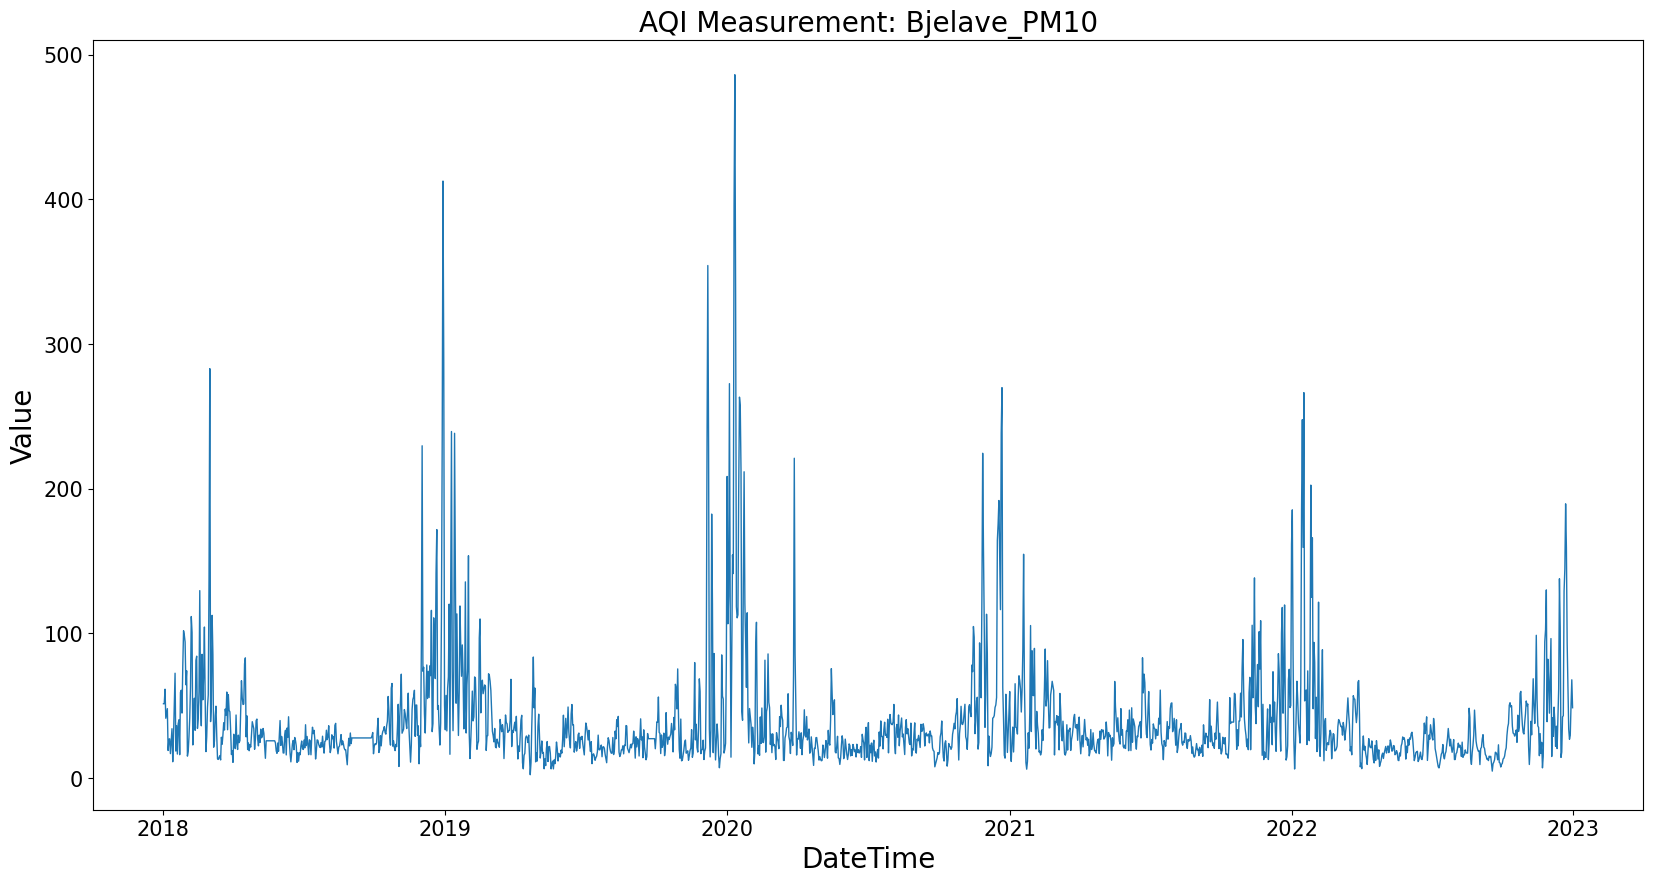

In [18]:
import matplotlib.pyplot as plt
#df_processed_combined_data_daily # Plot time seris data for columns, each with its own title
plt.figure(figsize=(20, 10))
plt.plot(df_processed_combined_data_daily['DateTime'], df_processed_combined_data_daily['Bjelave_PM10'], linewidth=1)

plt.xlabel('DateTime', fontsize=20)
plt.ylabel('Value', fontsize=20)
plt.title(f'AQI Measurement: Bjelave_PM10', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [19]:
def plot_forecast(test, forecast, date_col='ds', true_label='y', predicted_label='yhat'):
    plt.figure(figsize=(10,6))
    plt.plot(test[date_col], test[true_label], label='Actual')
    plt.plot(test[date_col], forecast[predicted_label], label='Predicted')
    plt.legend()
    plt.xlabel('Date')
    plt.ylabel(true_label)
    plt.title('Actual vs Predicted ' + true_label)
    plt.show()

# Dataset splitting

In [7]:
def train_test_split(df, date):
    df = df.copy()
    train_data = df[df['DateTime'] < date].copy()
    test_data = df[df['DateTime'] >= date].copy() # df.DateTime = df.DateTime.dt.strftime('%d/%m/%Y %H:%M')
    return train_data, test_data

def train_test_split_from_to(df, start_date, end_date, slice_date):
    df = df.copy()
    train_data = df[(df['DateTime'] >= start_date) & (df['DateTime'] < slice_date)].copy()
    test_data = df[(df['DateTime'] >= slice_date) & (df['DateTime'] <= end_date)].copy()
    return train_data, test_data

def plot_train_test_data(train_data, test_data, date_column, label):
    plt.figure(figsize=(20,10))
    plt.plot(train_data[date_column], train_data[label], color='blue', label='Train Data')
    plt.plot(test_data[date_column], test_data[label], color='orange', label='Test Data')
    plt.xlabel(date_column)
    plt.ylabel(label)
    plt.title(label + ' Train and Test Data')
    plt.legend()
    plt.show()

In [8]:
#input window = 30
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=30)
train_data_combined_ws_thirty, test_data_combined_ws_thirty = train_test_split(df_processed_combined_data_daily, date)

#input window = 60
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=60)
train_data_combined_ws_sixty, test_data_combined_ws_sixty = train_test_split(df_processed_combined_data_daily, date)

In [9]:
#input window = 90
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=90)
train_data_combined_ws_ninety, test_data_combined_ws_ninety = train_test_split(df_processed_combined_data_daily, date) #

#input window = 180
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=180)
train_data_combined_ws_oneHundredEighty, test_data_combined_ws_oneHundredEighty = train_test_split(df_processed_combined_data_daily, date) #

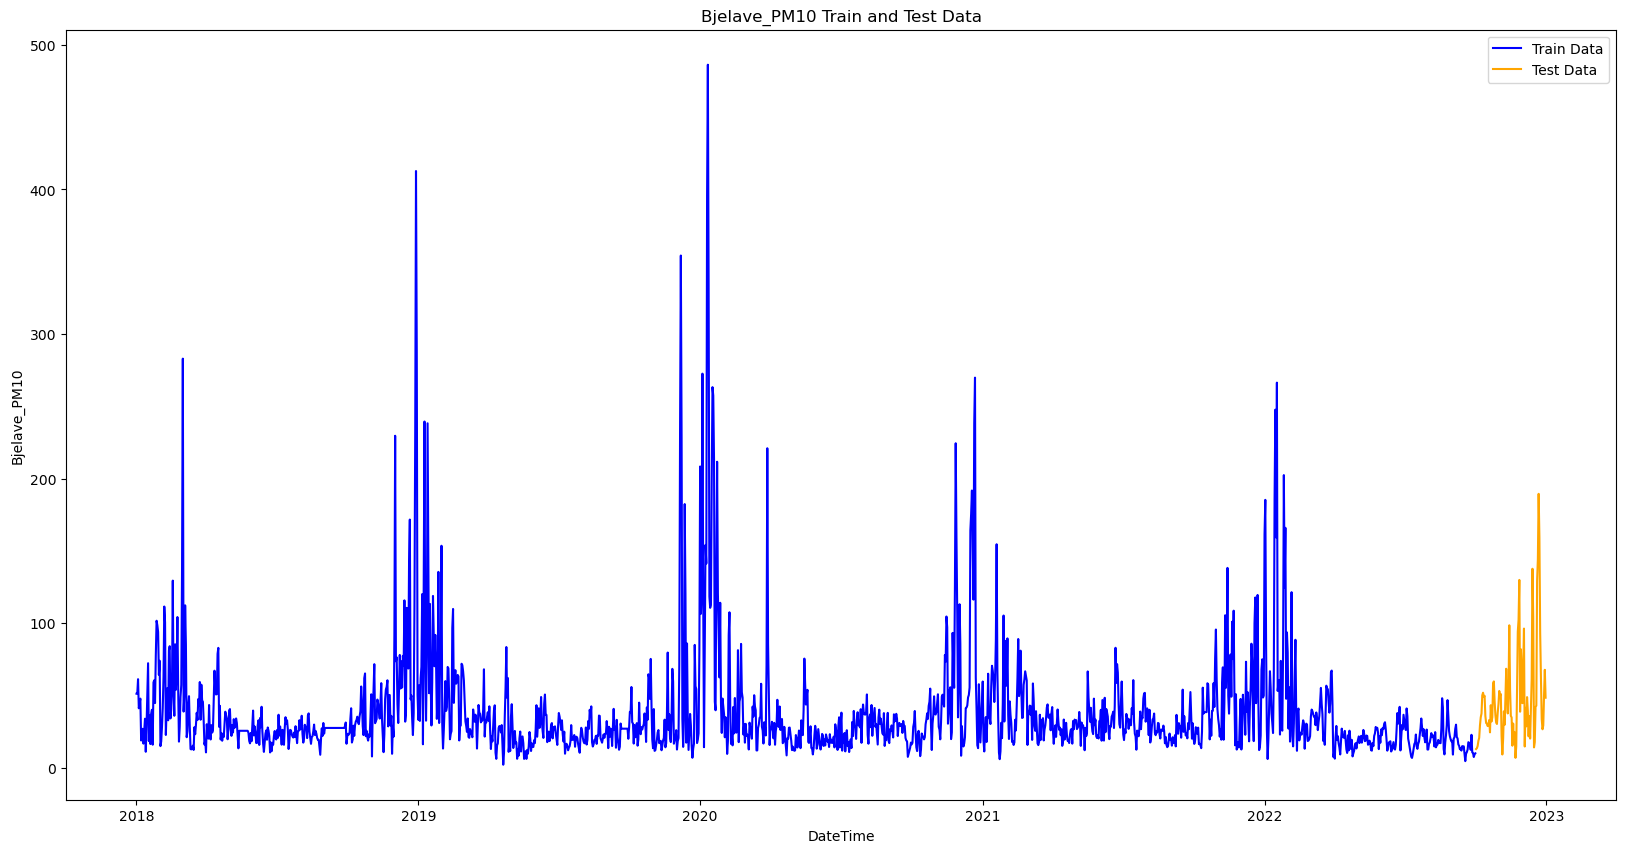

In [10]:
plot_train_test_data(train_data_combined_ws_ninety, test_data_combined_ws_ninety, 'DateTime', 'Bjelave_PM10')

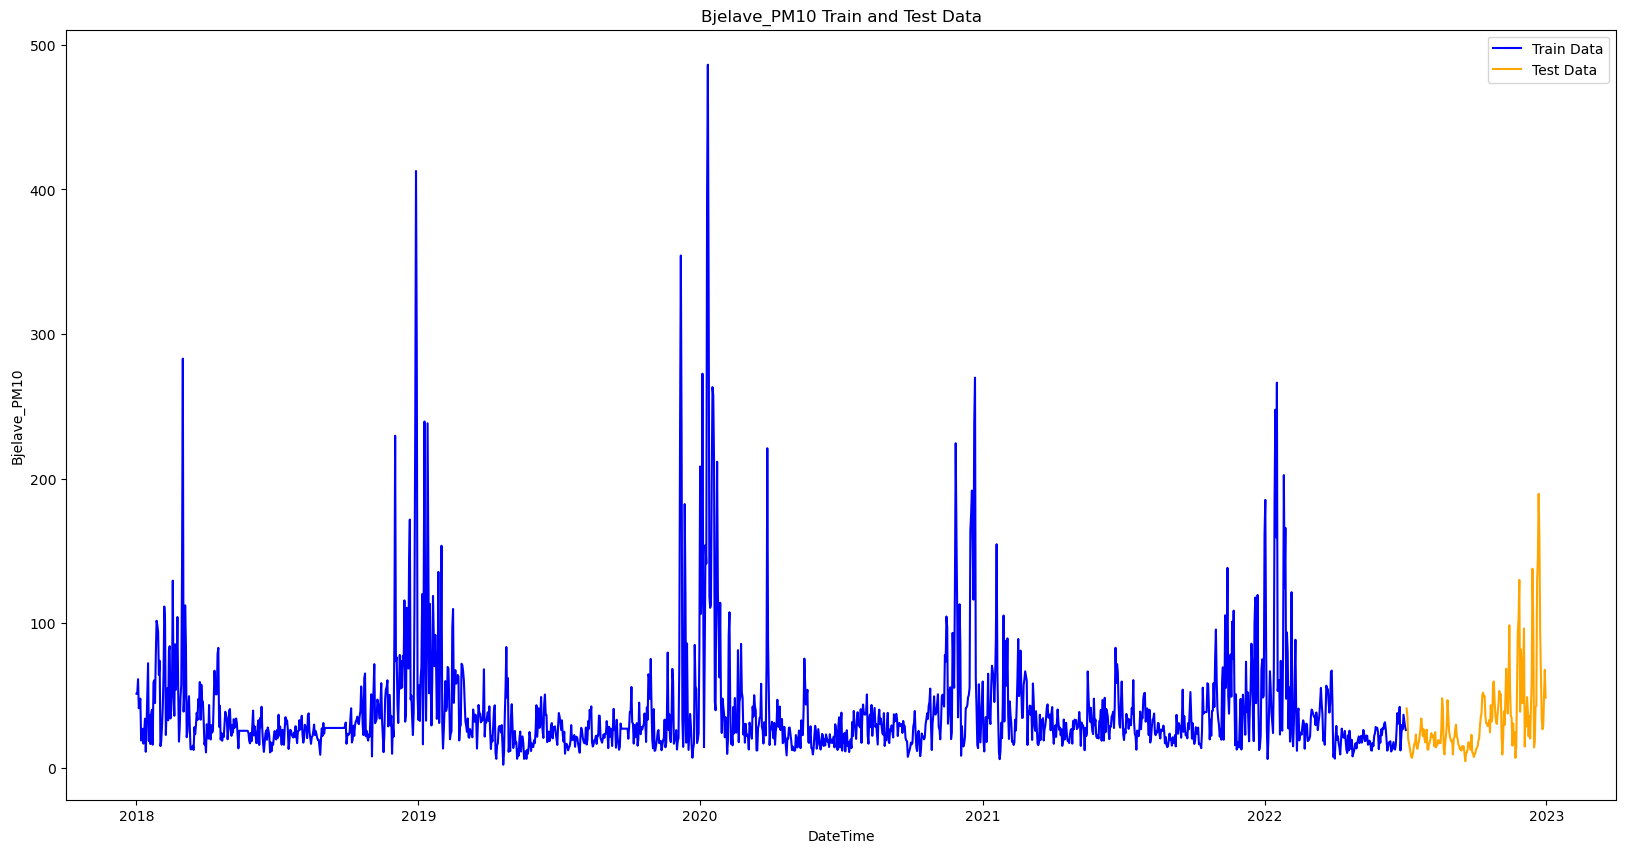

In [11]:
plot_train_test_data(train_data_combined_ws_oneHundredEighty, test_data_combined_ws_oneHundredEighty, 'DateTime', 'Bjelave_PM10')

# Multivariate Time Series Forecasting using FBProphet

In [20]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

In [21]:
train_data_combined_ws_thirty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_thirty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

train_data_combined_ws_sixty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_sixty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

In [22]:
train_data_combined_ws_ninety.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_ninety.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

train_data_combined_ws_oneHundredEighty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_oneHundredEighty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

In [23]:
def train_prophet_multivariate(train_data):
    model = Prophet()
    #added
    model.add_regressor('wind_speed')
    model.add_regressor('wind_direction')
    model.add_regressor('precipitation')
    model.add_regressor('pressure')
    model.add_regressor('temperature')
    model.add_regressor('humidity')
    model.add_regressor('visibility')
    model.add_regressor('cloudiness') #model.add_regressor('Bjelave_PM10')
    model.add_regressor('Bjelave_SO2')
    model.add_regressor('Bjelave_NO2')
    #added
    model.fit(train_data)
    return model
def predict_prophet(model, test_data):
    forecast = model.predict(test_data)
    return forecast

def calculate_metrics(test, forecast, true_label='y', predicted_label='yhat'):
    mae = mean_absolute_error(test[true_label], forecast[predicted_label])
    mse = mean_squared_error(test[true_label], forecast[predicted_label])
    rmse = sqrt(mse)
    r2 = r2_score(test[true_label], forecast[predicted_label])
    return rmse, mae, r2

def plot_boxplot(prediction_data, test_data):
    error = abs(prediction_data - test_data)
    # plot boxplot of error
    plt.figure(figsize=(10,6))
    plt.boxplot(error)
    plt.show()

In [24]:
model_combined_ws_thirty = train_prophet_multivariate(train_data_combined_ws_thirty)
forecast_combined_ws_thirty = predict_prophet(model_combined_ws_thirty, test_data_combined_ws_thirty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_thirty, forecast_combined_ws_thirty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

15:24:55 - cmdstanpy - INFO - Chain [1] start processing
15:24:56 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 27.266
MAE: 23.778
R2: 0.642


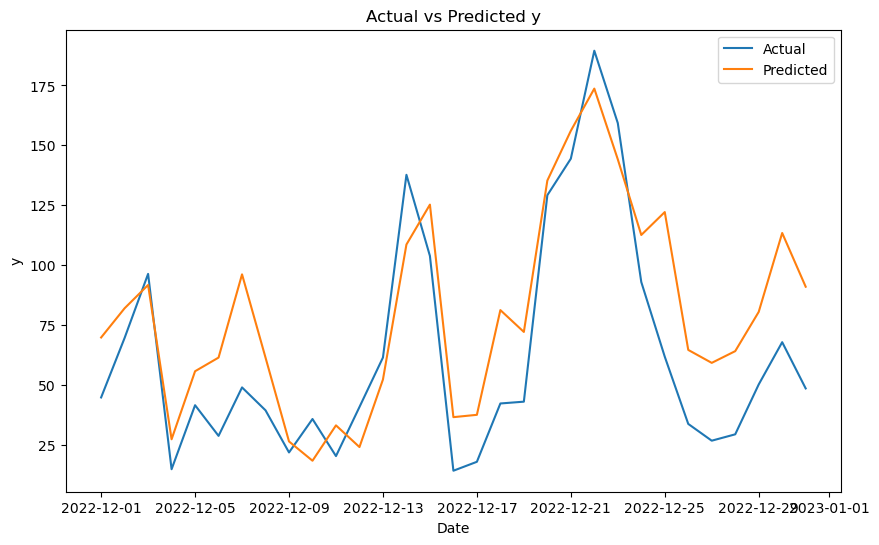

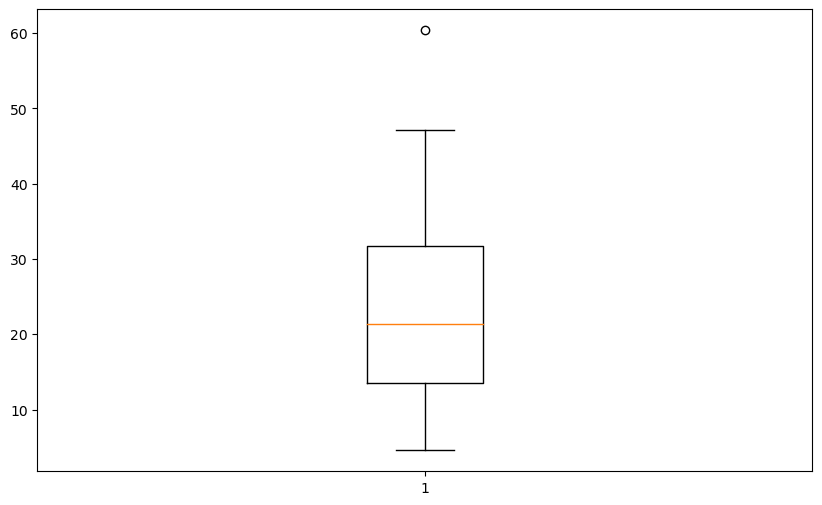

In [25]:
plot_forecast(test_data_combined_ws_thirty, forecast_combined_ws_thirty)
plot_boxplot(forecast_combined_ws_thirty['yhat'].values.reshape(-1,1), test_data_combined_ws_thirty['y'].values.reshape(-1,1))

In [26]:
model_combined_ws_sixty = train_prophet_multivariate(train_data_combined_ws_sixty)
forecast_combined_ws_sixty = predict_prophet(model_combined_ws_sixty, test_data_combined_ws_sixty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_sixty, forecast_combined_ws_sixty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

15:24:57 - cmdstanpy - INFO - Chain [1] start processing
15:24:58 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 23.206
MAE: 19.322
R2: 0.650


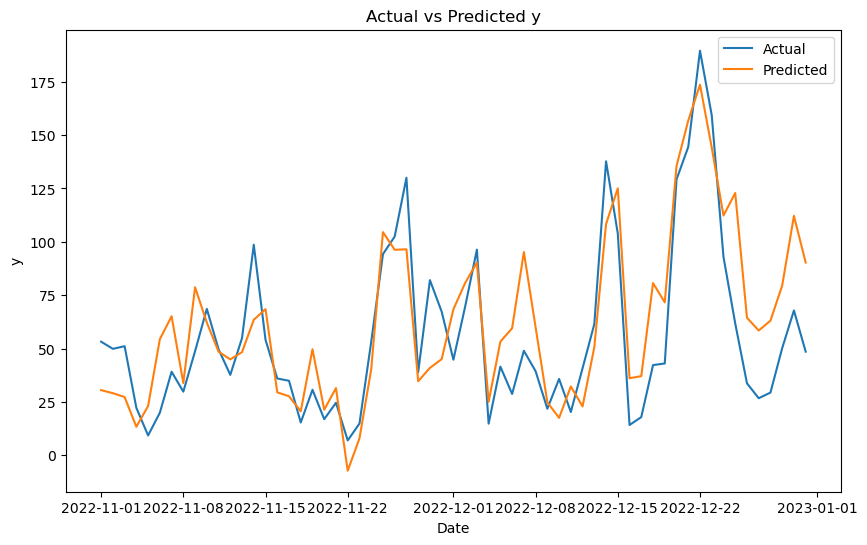

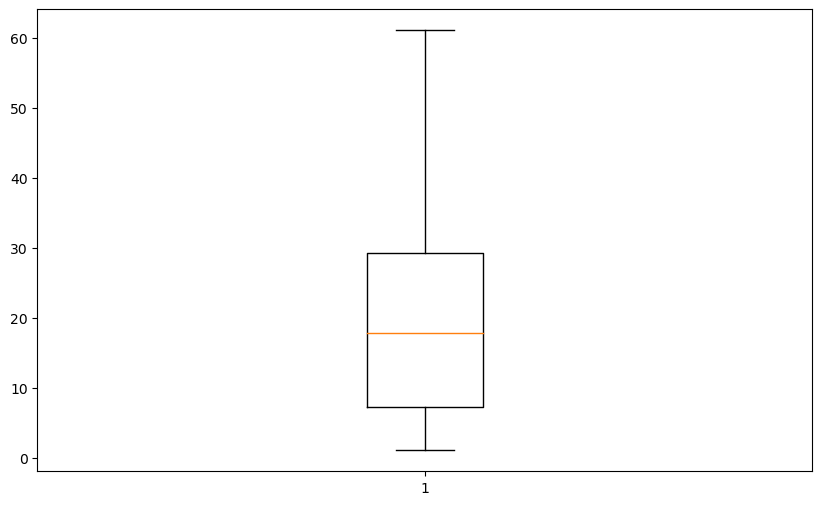

In [27]:
plot_forecast(test_data_combined_ws_sixty, forecast_combined_ws_sixty)
plot_boxplot(forecast_combined_ws_sixty['yhat'].values.reshape(-1,1), test_data_combined_ws_sixty['y'].values.reshape(-1,1))

In [28]:
model_combined_ws_ninety = train_prophet_multivariate(train_data_combined_ws_ninety)
forecast_combined_ws_ninety = predict_prophet(model_combined_ws_ninety, test_data_combined_ws_ninety)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_ninety, forecast_combined_ws_ninety)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

15:24:59 - cmdstanpy - INFO - Chain [1] start processing
15:25:00 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 19.723
MAE: 15.692
R2: 0.669


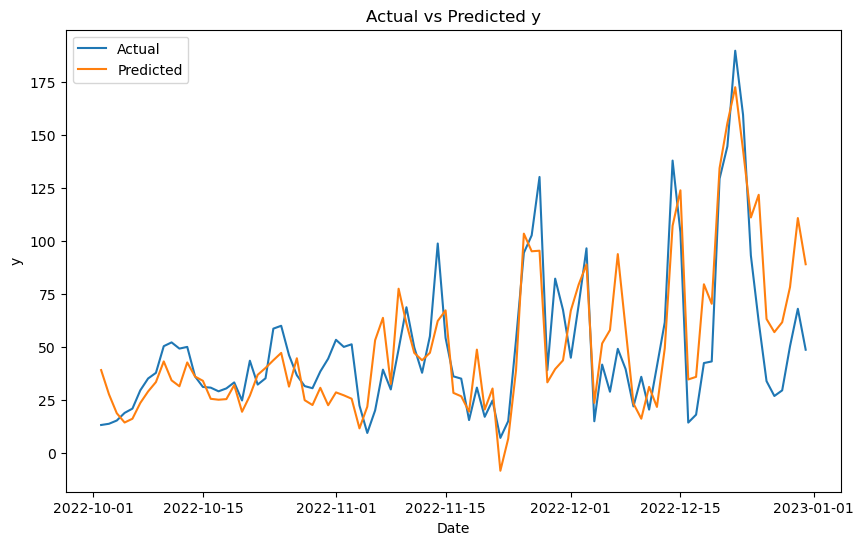

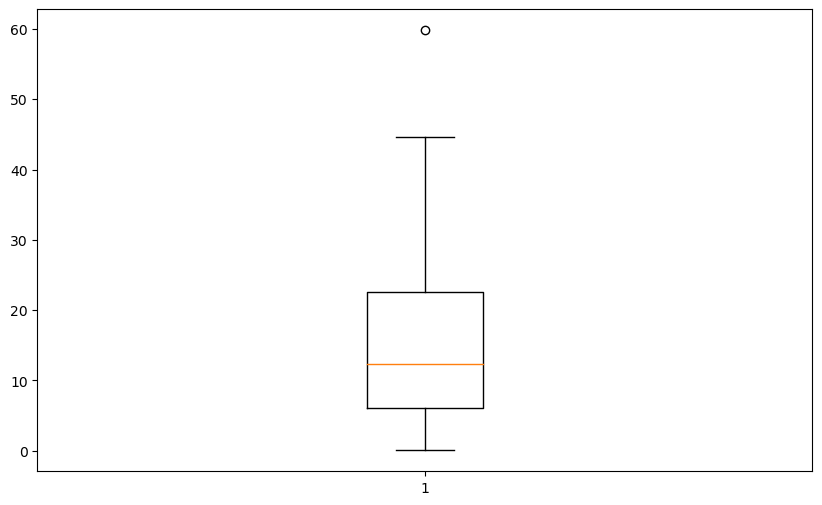

In [29]:
plot_forecast(test_data_combined_ws_ninety, forecast_combined_ws_ninety)
plot_boxplot(forecast_combined_ws_ninety['yhat'].values.reshape(-1,1), test_data_combined_ws_ninety['y'].values.reshape(-1,1))

In [30]:
model_combined_ws_oneHundredEighty = train_prophet_multivariate(train_data_combined_ws_oneHundredEighty)
forecast_combined_ws_oneHundredEighty = predict_prophet(model_combined_ws_oneHundredEighty, test_data_combined_ws_oneHundredEighty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_oneHundredEighty, forecast_combined_ws_oneHundredEighty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

15:25:01 - cmdstanpy - INFO - Chain [1] start processing
15:25:01 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 17.286
MAE: 13.057
R2: 0.648


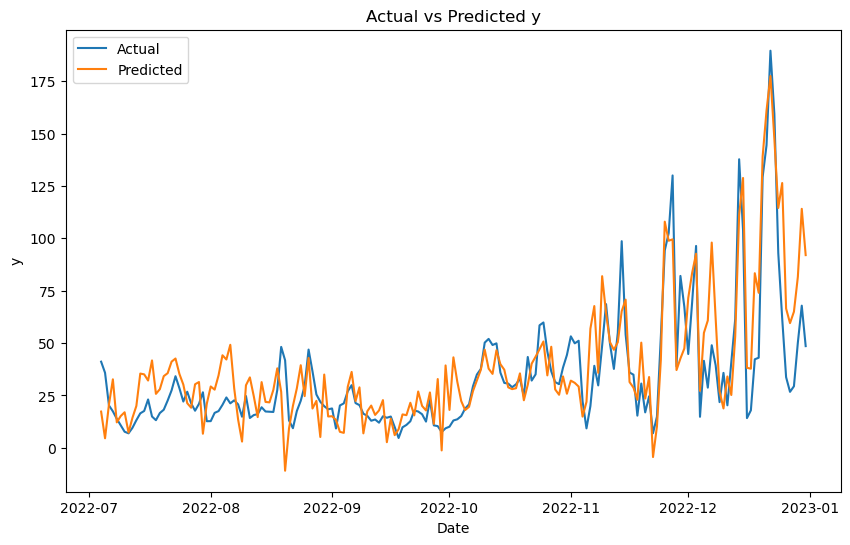

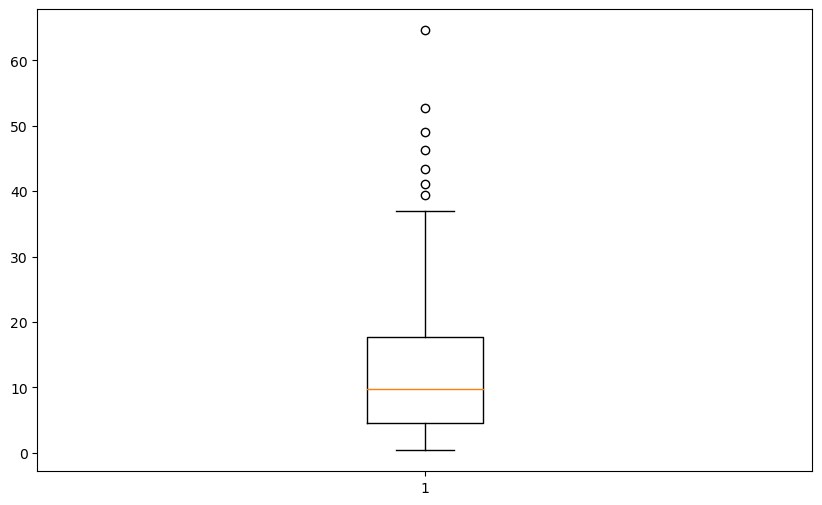

In [31]:
plot_forecast(test_data_combined_ws_oneHundredEighty, forecast_combined_ws_oneHundredEighty)
plot_boxplot(forecast_combined_ws_oneHundredEighty['yhat'].values.reshape(-1,1), test_data_combined_ws_oneHundredEighty['y'].values.reshape(-1,1))

# Prerequisites and Data Preparation for SHAP Analysis of Facebook Prophet Models


In [32]:
import shap
#backgraound data je citav dataset
#testirano na 100 uzoraka inace (samo ws 30 i 60)
background_data_combined_ws_thirty = shap.sample(train_data_combined_ws_thirty, 100)
background_data_combined_ws_sixty= shap.sample(train_data_combined_ws_sixty, 100)
background_data_combined_ws_ninety = shap.sample(train_data_combined_ws_ninety, 100)
background_data_combined_ws_oneHundredEighty = shap.sample(train_data_combined_ws_oneHundredEighty, 100)

In [33]:
feature_columns_combined=['ds', 'y','wind_speed','wind_direction','precipitation','pressure', 'temperature','humidity','visibility','cloudiness','Bjelave_SO2','Bjelave_NO2']
feature_columns_aqi=['ds','y']

In [34]:
def prophet_predict_ws_thirty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_thirty.predict(data_df)
    return predictions['yhat'].values

def prophet_predict_ws_sixty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_sixty.predict(data_df)
    return predictions['yhat'].values


def prophet_predict_ws_ninety_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_ninety.predict(data_df)
    return predictions['yhat'].values

def prophet_predict_ws_oneHundredEighty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_oneHundredEighty.predict(data_df)
    return predictions['yhat'].values

In [35]:
data_combined_to_explain_ws_thirty=test_data_combined_ws_thirty.rename(columns={'y': 'yhat'})
data_combined_to_explain_ws_sixty=test_data_combined_ws_sixty.rename(columns={'y': 'yhat'})
data_combined_to_explain_ws_ninety=test_data_combined_ws_ninety.rename(columns={'y': 'yhat'})
data_combined_to_explain_ws_oneHundredEighty=test_data_combined_ws_oneHundredEighty.rename(columns={'y': 'yhat'})


In [36]:
print("len(data_combined_to_explain_ws_thirty)", len(data_combined_to_explain_ws_thirty))
print("len(data_combined_to_explain_ws_sixty)", len(data_combined_to_explain_ws_sixty))
print("len(data_combined_to_explain_ws_ninety)", len(data_combined_to_explain_ws_ninety))
print("len(data_combined_to_explain_ws_oneHundredEighty)", len(data_combined_to_explain_ws_oneHundredEighty))

len(data_combined_to_explain_ws_thirty) 31
len(data_combined_to_explain_ws_sixty) 61
len(data_combined_to_explain_ws_ninety) 91
len(data_combined_to_explain_ws_oneHundredEighty) 181


# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=30]


In [37]:
custom_feature_names = [
    'Bjelave_PM10' if col == 'yhat' else
    'DateTime' if col == 'ds' else
    col
    for col in data_combined_to_explain_ws_thirty.columns
]

In [38]:
custom_feature_names


['DateTime',
 'wind_speed',
 'wind_direction',
 'precipitation',
 'pressure',
 'temperature',
 'humidity',
 'visibility',
 'cloudiness',
 'Bjelave_PM10',
 'Bjelave_SO2',
 'Bjelave_NO2']

In [ ]:
explainer_data_combined_ws_thirty = shap.KernelExplainer(prophet_predict_ws_thirty_for_shap_combined, background_data_combined_ws_thirty)
shap_values_data_combined_ws_thirty = explainer_data_combined_ws_thirty.shap_values(data_combined_to_explain_ws_thirty)

Using 1795 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
  0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
explainer_data_combined_ws_thirty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_thirty,
    base_values=np.array([explainer_data_combined_ws_thirty.expected_value] * len(shap_values_data_combined_ws_thirty)),
    data=data_combined_to_explain_ws_thirty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

In [ ]:
explainer_data_combined_ws_thirty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_thirty,
    base_values=np.array([explainer_data_combined_ws_thirty.expected_value] * len(shap_values_data_combined_ws_thirty)),
    data=data_combined_to_explain_ws_thirty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=60]


In [ ]:
explainer_data_combined_ws_sixty = shap.KernelExplainer(prophet_predict_ws_sixty_for_shap_combined, background_data_combined_ws_sixty)
shap_values_data_combined_ws_sixty = explainer_data_combined_ws_sixty.shap_values(data_combined_to_explain_ws_sixty)

In [ ]:
explainer_data_combined_ws_sixty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_sixty,
    base_values=np.array([explainer_data_combined_ws_sixty.expected_value] * len(shap_values_data_combined_ws_sixty)),
    data=data_combined_to_explain_ws_sixty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_sixty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_sixty_mod, max_display=len(custom_feature_names))

In [ ]:
df1 = pd.DataFrame({
    "Index": list(range(len(background_data_combined_ws_sixty.columns))),
    "Background Columns": background_data_combined_ws_sixty.columns
})
df2 = pd.DataFrame({
    "Index": list(range(len(data_combined_to_explain_ws_sixty.columns))),
    "To Explain Columns": data_combined_to_explain_ws_sixty.columns
})
combined = pd.merge(df1, df2, on="Index", how="outer")
print(combined)

In [ ]:
custom_feature_names_trimmed = custom_feature_names[1:]
custom_feature_names_trimmed[0]

# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=90]

In [ ]:
explainer_data_combined_ws_ninety = shap.KernelExplainer(prophet_predict_ws_ninety_for_shap_combined, background_data_combined_ws_ninety)
shap_values_data_combined_ws_ninety = explainer_data_combined_ws_ninety.shap_values(data_combined_to_explain_ws_ninety)

In [ ]:
explainer_data_combined_ws_ninety_mod = shap.Explanation(
    values=shap_values_data_combined_ws_ninety,
    base_values=np.array([explainer_data_combined_ws_ninety.expected_value] * len(shap_values_data_combined_ws_ninety)),
    data=data_combined_to_explain_ws_ninety,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_ninety_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_ninety_mod, max_display=len(custom_feature_names))

# NE!     SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=180]


In [ ]:
explainer_data_combined_ws_oneHundredEighty = shap.KernelExplainer(prophet_predict_ws_oneHundredEighty_for_shap_combined, background_data_combined_ws_oneHundredEighty)
shap_values_data_combined_ws_oneHundredEighty = explainer_data_combined_ws_oneHundredEighty.shap_values(data_combined_to_explain_ws_oneHundredEighty)

In [ ]:
explainer_data_combined_ws_oneHundredEighty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_oneHundredEighty,
    base_values=np.array([explainer_data_combined_ws_oneHundredEighty.expected_value] * len(shap_values_data_combined_ws_oneHundredEighty)),
    data=data_combined_to_explain_ws_oneHundredEighty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_oneHundredEighty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_oneHundredEighty_mod, max_display=len(custom_feature_names))

# Dependence Plots for Window Size 60 (FB Prophet Model)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

# Dependence Plots for Window Size 90 (FB Prophet Model)


In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

# Dependence Plots for Window Size 30 (FB Prophet Model)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)